In [271]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [273]:
data = pd.read_csv('glass.csv')


In [275]:
data

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [277]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [279]:
 data.drop('Fe',axis = 1,inplace = True)

In [281]:
data.sample(15)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Type
100,1.51655,12.75,2.85,1.44,73.27,0.57,8.79,0.11,2
63,1.52227,14.17,3.81,0.78,71.35,0.00,9.69,0.00,1
118,1.51673,13.30,3.64,1.53,72.53,0.65,8.03,0.00,2
137,1.51711,12.89,3.62,1.57,72.96,0.61,8.11,0.00,2
58,1.51754,13.48,3.74,1.17,72.99,0.59,8.03,0.00,1
72,1.51593,13.09,3.59,1.52,73.10,0.67,7.83,0.00,2
130,1.52177,13.75,1.01,1.36,72.19,0.33,11.14,0.00,2
121,1.51663,12.93,3.54,1.62,72.96,0.64,8.03,0.00,2
200,1.51508,15.15,0.00,2.25,73.50,0.00,8.34,0.63,7
133,1.51800,13.71,3.93,1.54,71.81,0.54,8.21,0.00,2


In [283]:
x = data.iloc[:,0:8]
y = data.iloc[:,-1]

In [285]:
print(x.shape)
print(y.shape)

(214, 8)
(214,)


In [287]:
print(type(x_train))

<class 'numpy.ndarray'>


In [293]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state = 0)

In [295]:
ss = StandardScaler()

In [302]:
x_train.iloc[:,[1,4,6]] = ss.fit_transform(x_train.iloc[:,[1,4,6]])
x_test.iloc[:,[1,4,6]]= ss.transform(x_test.iloc[:,[1,4,6]])

In [348]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [350]:
x_train_pca.shape

(171, 2)

In [356]:
x_test_pca.shape

(43, 2)

In [410]:
#Befor Using PCA
from sklearn.metrics import accuracy_score

scores = []

for i in range(1,20):
    
    knn =  KNeighborsClassifier(i) 
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    
    accuracy = accuracy_score(y_test,y_pred)
    scores.append(accuracy)
    
    print(f'kvalue: {i} and accuracy score :\n {accuracy} \n' )

kvalue: 1 and accuracy score :
 0.5813953488372093 

kvalue: 2 and accuracy score :
 0.5581395348837209 

kvalue: 3 and accuracy score :
 0.627906976744186 

kvalue: 4 and accuracy score :
 0.627906976744186 

kvalue: 5 and accuracy score :
 0.627906976744186 

kvalue: 6 and accuracy score :
 0.5813953488372093 

kvalue: 7 and accuracy score :
 0.5581395348837209 

kvalue: 8 and accuracy score :
 0.5813953488372093 

kvalue: 9 and accuracy score :
 0.5348837209302325 

kvalue: 10 and accuracy score :
 0.5813953488372093 

kvalue: 11 and accuracy score :
 0.5813953488372093 

kvalue: 12 and accuracy score :
 0.627906976744186 

kvalue: 13 and accuracy score :
 0.6046511627906976 

kvalue: 14 and accuracy score :
 0.6046511627906976 

kvalue: 15 and accuracy score :
 0.5813953488372093 

kvalue: 16 and accuracy score :
 0.5581395348837209 

kvalue: 17 and accuracy score :
 0.5348837209302325 

kvalue: 18 and accuracy score :
 0.5348837209302325 

kvalue: 19 and accuracy score :
 0.534883

In [412]:
#After PCA
from sklearn.metrics import accuracy_score

scores1 = []

for i in range(1,20):
    
    knn =  KNeighborsClassifier(i) 
    knn.fit(x_train_pca,y_train)
    y_pred = knn.predict(x_test_pca)
    
    accuracy1 = accuracy_score(y_test,y_pred)
    scores1.append(accuracy1)
    
    print(f'kvalue: {i} and accuracy score :\n {accuracy1} \n' )

kvalue: 1 and accuracy score :
 0.4186046511627907 

kvalue: 2 and accuracy score :
 0.46511627906976744 

kvalue: 3 and accuracy score :
 0.37209302325581395 

kvalue: 4 and accuracy score :
 0.4418604651162791 

kvalue: 5 and accuracy score :
 0.5813953488372093 

kvalue: 6 and accuracy score :
 0.5116279069767442 

kvalue: 7 and accuracy score :
 0.5348837209302325 

kvalue: 8 and accuracy score :
 0.4883720930232558 

kvalue: 9 and accuracy score :
 0.4883720930232558 

kvalue: 10 and accuracy score :
 0.5348837209302325 

kvalue: 11 and accuracy score :
 0.5116279069767442 

kvalue: 12 and accuracy score :
 0.46511627906976744 

kvalue: 13 and accuracy score :
 0.5116279069767442 

kvalue: 14 and accuracy score :
 0.5116279069767442 

kvalue: 15 and accuracy score :
 0.5116279069767442 

kvalue: 16 and accuracy score :
 0.4883720930232558 

kvalue: 17 and accuracy score :
 0.5581395348837209 

kvalue: 18 and accuracy score :
 0.5348837209302325 

kvalue: 19 and accuracy score :
 0

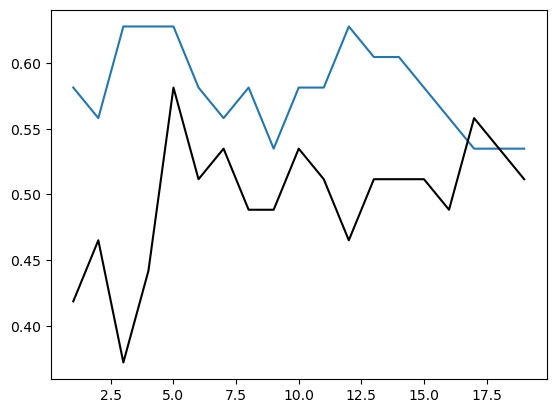

In [414]:
import matplotlib.pyplot as plt

plt.plot(range(1,20),scores)
plt.plot(range(1,20),scores1,color= 'black')  #after applying PCA

In [420]:
 knn1 =  KNeighborsClassifier(5) 
 knn1.fit(x_train_pca,y_train)
 y_pred1 = knn.predict(x_test_pca)
 accuracy1 = accuracy_score(y_test,y_pred1)

In [432]:
 knn2 =  KNeighborsClassifier(5) 
 knn2.fit(x_train,y_train)
 y_pred2 = knn2.predict(x_test)
 accuracy1 = accuracy_score(y_test,y_pred2)

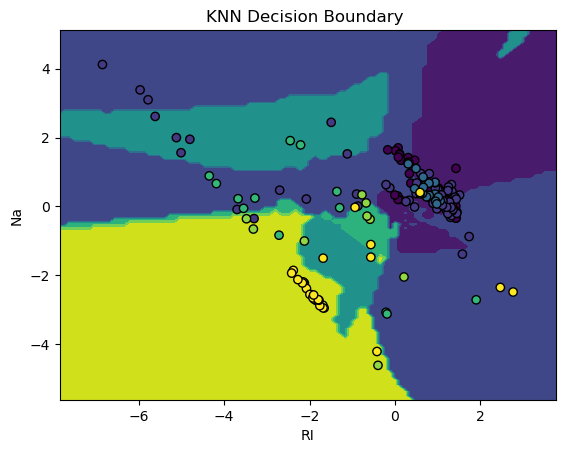

In [434]:
from sklearn.inspection import DecisionBoundaryDisplay
DecisionBoundaryDisplay.from_estimator(
    knn1,
    x,
    cmap="viridis",
    response_method="predict"
)
plt.scatter(x[:, 0], x[:, 1],c=y, edgecolor="k")
plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.title("KNN Decision Boundary ")
plt.show()


In [466]:
X_plot = x[:,[0, 1]]

knn_plot = KNeighborsClassifier(n_neighbors=5)

knn_plot.fit(X_plot, y)

KNeighborsClassifier()

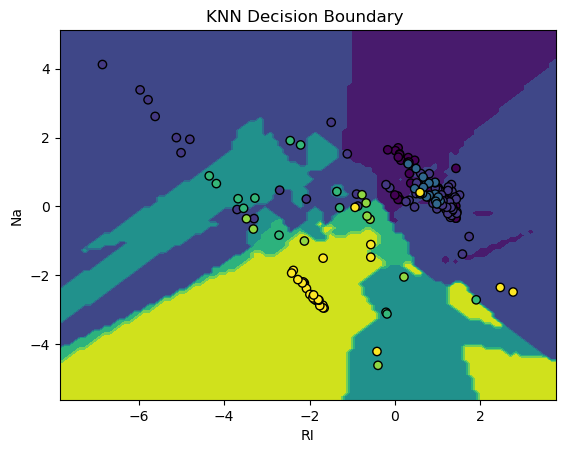

In [468]:
from sklearn.inspection import DecisionBoundaryDisplay
DecisionBoundaryDisplay.from_estimator(
    knn_plot,
    X_plot,
    cmap="viridis",
    response_method="predict"
)
plt.scatter(x[:, 0], x[:, 1],c=y, edgecolor="k")
plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.title("KNN Decision Boundary ")
plt.show()
